In [ ]:
import numpy as np
import numba as nb
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import torch
from kan import KAN
import re
import sys
from io import StringIO
import contextlib

from tqdm import tqdm

# ----------------------------
# Settings
# ----------------------------
n_paths_max = 10000
dt = 1.0  # one calendar-day step (used for OLS calibration on trading-day data)
seed = 123

forward_csv_path = "../data/forward_prices.csv"

# ----------------------------
# Load spot data
# ----------------------------
with open("../data/THE_gas.txt", "r", encoding="utf-8") as f:
    txt = " ".join(f.readlines())

dates_str = re.search(r"labels:\s*\[(.*?)\]", txt).group(1)
dates = [d.replace("'", "").strip() for d in dates_str.split(",")]

prices_str = re.search(r"data:\s*\[(.*?)\]", txt).group(1)
prices = [p.strip() for p in prices_str.split(",")]
prices = [np.nan if p == "" else float(p) for p in prices]

data = pd.DataFrame({
    "date":       pd.to_datetime(dates, format="%d.%m.%Y"),
    "spot_price": prices,
})

data = (
    data
    .dropna(subset=["spot_price"])
    .loc[(data["date"] >= "2024-01-02") & (data["date"] <= "2025-12-31")]
    .sort_values("date")
    .drop_duplicates(subset=["date"])
    .reset_index(drop=True)
)

# ----------------------------
# Load forward curve
# ----------------------------
forward_curve = pd.read_csv(forward_csv_path)
forward_curve["date"] = pd.to_datetime(forward_curve["date"]).dt.normalize()

# ----------------------------
# Joint estimation of seasonality + AR(1)
# ----------------------------
data["t"]     = (data["date"] - data["date"].iloc[0]).dt.days.astype(float)
data["X"]     = np.log(data["spot_price"].astype(float))
data["X_lag"] = data["X"].shift(1)

reg_df = data.dropna(subset=["X", "X_lag"]).copy()
t_reg  = reg_df["t"].to_numpy()

sin1 = np.sin(2.0 * np.pi * t_reg / 365.0)
cos1 = np.cos(2.0 * np.pi * t_reg / 365.0)

Xreg      = sm.add_constant(np.column_stack([reg_df["X_lag"].to_numpy(), sin1, cos1]))
fit_joint = sm.OLS(reg_df["X"].to_numpy(), Xreg).fit()

const_hat     = float(fit_joint.params[0])
b_hat         = float(fit_joint.params[1])
c1_hat        = float(fit_joint.params[2])
c2_hat        = float(fit_joint.params[3])
sigma_eta_hat = float(np.std(fit_joint.resid, ddof=1))

kappa_hat = -np.log(b_hat) / dt
sigma_hat = np.sqrt(
    (sigma_eta_hat**2) * 2.0 * kappa_hat / (1.0 - np.exp(-2.0 * kappa_hat * dt))
)

# ----------------------------
# Build calendar-day simulation grid
# (forward_prices.csv already has all calendar days — direct merge)
# ----------------------------
_cal_start = data["date"].iloc[0]
_cal_end   = data["date"].iloc[-1]
sim_df = pd.DataFrame({"date": pd.date_range(_cal_start, _cal_end, freq="D")})
sim_df = sim_df.merge(forward_curve, on="date", how="inner")
sim_df = sim_df.sort_values("date").reset_index(drop=True)

data  = sim_df.copy()
data["t"]   = (data["date"] - data["date"].iloc[0]).dt.days.astype(float)
data["F0t"] = data["forward_price"].astype(float)

Tn    = len(data)
t_arr = data["t"].to_numpy()

var_X  = (sigma_hat**2 / (2.0 * kappa_hat)) * (1.0 - np.exp(-2.0 * kappa_hat * t_arr))
m      = np.log(data["F0t"].to_numpy()) - 0.5 * var_X
m_col  = m[:, None]

# ----------------------------
# Simulate paths (antithetic normals)
# ----------------------------
rng    = np.random.default_rng(seed)
n_half = int(np.ceil(n_paths_max / 2))
Z_half = rng.standard_normal(size=(Tn - 1, n_half))
Z      = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_paths_max]

def simulate_from_Z(Z, *, n_paths, Tn, t_arr, kappa_hat, sigma_hat, m_col):
    Z_use = Z[:, :n_paths]
    Y = np.zeros((Tn, n_paths), dtype=np.float64)
    for i in range(1, Tn):
        h     = t_arr[i] - t_arr[i - 1]
        phi_h = np.exp(-kappa_hat * h)
        sd_h  = np.sqrt(sigma_hat**2 / (2.0 * kappa_hat) * (1.0 - np.exp(-2.0 * kappa_hat * h)))
        Y[i]  = phi_h * Y[i - 1] + sd_h * Z_use[i - 1]
    return np.exp(Y + m_col)

# ============================================================
# MODEL PARAMETERS — defined before any arrays that depend on them
# ============================================================
alpha_c          = 40000.0
refine_factor    = 16
alpha_f          = alpha_c / refine_factor   # 2 500

r_annual         = 0.1
terminal_penalty = -np.inf

# KAN hyper-parameters
KAN_HIDDEN = 4
KAN_GRID   = 3
KAN_K      = 3
KAN_STEPS  = 5
KAN_LAMBDA = 0.0
KAN_OPT    = "LBFGS"
KAN_MAX_TRAIN_SAMPLES = n_paths_max
KAN_BATCH  = KAN_MAX_TRAIN_SAMPLES  # full batch
DEVICE     = torch.device("cpu")

# Step-varying discount: accounts for multi-day gaps (e.g. 3 days for Fri->Mon, 5 for Easter/Christmas)
disc_arr = np.exp(-r_annual * np.diff(t_arr) / 365.0)   # shape (T,), disc_arr[t] for step t->t+1

# ============================================================
# Constraint helpers
# ============================================================

# ---------- vmax: constant ----------
VMAX_CONST = 10_125_000.0

# ---------- Rate caps ----------
INJECTMAX_BASE = 3_780.0 * 24.0
WDRMAX_BASE    = 7_500.0 * 24.0

# ---------- vmin: technical-feasibility floor from dated anchors ----------
# Use the same approach as GSD_min_max_inventory_constraints.ipynb:
# at each date, require enough inventory to still be able to reach every
# future anchor under maximum daily injection.
VMIN_BASE = 0.0
_VMIN_CYCLE_START = pd.Timestamp("2024-01-01")
_VMIN_CYCLE_LENGTH = 365 + 366
# Anchor dates are exact calendar dates — no snapping needed.
_RAW_ANCHOR_DATES = pd.to_datetime([
    "2024-02-01",
    "2024-05-01",
    "2024-07-01",
    "2024-09-01",
    "2024-11-01",
    "2025-02-01",
    "2025-05-01",
    "2025-07-01",
    "2025-09-01",
    "2025-11-01",
])
_VMIN_ANCHOR_DATES = pd.DatetimeIndex(_RAW_ANCHOR_DATES)
_VMIN_ANCHOR_VALUES = VMAX_CONST * np.array([
    0.45, 0.40, 0.60, 0.80, 0.90,
    0.45, 0.40, 0.60, 0.75, 0.90,
], dtype=np.float64)
_VMIN_ANCHOR_X = (_VMIN_ANCHOR_DATES - _VMIN_CYCLE_START).days.to_numpy()
# Include previous/current/next cycles so the floor respects both
# backward-looking withdrawal feasibility and forward-looking injection
# feasibility across the two-year repeating pattern.
_VMIN_ANCHOR_X_ALL = np.r_[
    _VMIN_ANCHOR_X - _VMIN_CYCLE_LENGTH,
    _VMIN_ANCHOR_X,
    _VMIN_ANCHOR_X + _VMIN_CYCLE_LENGTH,
]
_VMIN_ANCHOR_Y_ALL = np.r_[
    _VMIN_ANCHOR_VALUES,
    _VMIN_ANCHOR_VALUES,
    _VMIN_ANCHOR_VALUES,
]

def feasible_vmin_for_dates(dates_like) -> np.ndarray:
    dates = pd.DatetimeIndex(dates_like)
    date_x = (dates - _VMIN_CYCLE_START).days.to_numpy()
    feasible_floor = np.empty(len(dates), dtype=np.float64)
    inj_max = INJECTMAX_BASE
    wdr_max = WDRMAX_BASE
    for i, t in enumerate(date_x):
        future_mask = _VMIN_ANCHOR_X_ALL >= t
        past_mask   = _VMIN_ANCHOR_X_ALL <= t

        days_to_future = _VMIN_ANCHOR_X_ALL[future_mask] - t
        days_from_past = t - _VMIN_ANCHOR_X_ALL[past_mask]

        required_for_future = (
            _VMIN_ANCHOR_Y_ALL[future_mask] - inj_max * days_to_future
        ).max()
        required_from_past = (
            _VMIN_ANCHOR_Y_ALL[past_mask] - wdr_max * days_from_past
        ).max()

        feasible_floor[i] = np.clip(
            max(required_for_future, required_from_past),
            VMIN_BASE,
            VMAX_CONST,
        )
    return feasible_floor

def vmin_at_date(date: pd.Timestamp) -> float:
    return float(feasible_vmin_for_dates(pd.DatetimeIndex([date]))[0])

def inj_cap(fill_frac: float) -> float:
    return (0.75 if fill_frac >= 0.95 else 1.00) * INJECTMAX_BASE

def wdr_cap(fill_frac: float) -> float:
    if   fill_frac <= 0.05:  cap = 0.25
    elif fill_frac <= 0.125: cap = 0.50
    elif fill_frac <= 0.15:  cap = 0.75
    elif fill_frac <= 0.20:  cap = 0.85
    else:                    cap = 1.00
    return cap * WDRMAX_BASE

# ============================================================
# Per-date constraint arrays  (alpha_f now defined above)
# ============================================================
dates_pd = pd.DatetimeIndex(data["date"].to_numpy())

vmax_arr = np.full(len(dates_pd), VMAX_CONST, dtype=np.float64)
vmin_arr = feasible_vmin_for_dates(dates_pd)

# v0 and vT_target: fixed level, snapped to fine grid
v_target_raw = 9_153_925.0
v0        = round(v_target_raw / alpha_f) * alpha_f
vT_target = round(v_target_raw / alpha_f) * alpha_f

print(f"v0        = {v0:>12,.0f}  (snapped from {v_target_raw:,.0f})")
print(f"vT_target = {vT_target:>12,.0f}  (snapped from {v_target_raw:,.0f})")
print(f"vmax range: {vmax_arr.min():,.0f} – {vmax_arr.max():,.0f}")
print(f"vmin range: {vmin_arr.min():,.0f} – {vmin_arr.max():,.0f}")


# ============================================================
# Volume grid
# ============================================================
VMIN_GLOBAL = 0.0
VMAX_GLOBAL = float(np.max(vmax_arr))

Nc = int(round((VMAX_GLOBAL - VMIN_GLOBAL) / alpha_c)) + 1
Nf = (Nc - 1) * refine_factor + 1

v_coarse        = VMIN_GLOBAL + alpha_c * np.arange(Nc, dtype=np.float64)
v_fine          = VMIN_GLOBAL + alpha_f * np.arange(Nf, dtype=np.float64)
coarse_fine_idx = (refine_factor * np.arange(Nc)).astype(np.int32)
assert coarse_fine_idx[-1] == Nf - 1, "Grid alignment check failed"

def fine_index_of(v: float) -> int:
    return int(round((v - VMIN_GLOBAL) / alpha_f))

n0_f  = fine_index_of(v0)
nT_f  = fine_index_of(vT_target)

print(f"\nGrid: Nc={Nc}, Nf={Nf}, n0_f={n0_f}, nT_f={nT_f}")

# ============================================================
# Terminal value: hard target at nT_f.
# ============================================================
def terminal_value(v_arr: np.ndarray) -> np.ndarray:
    tv = np.full_like(v_arr, terminal_penalty, dtype=np.float64)
    tv[nT_f] = 0.0
    return tv

# ============================================================
# Feasible action sets — one per timestep
# ============================================================
def build_feasible_actions_at_t(t_idx: int):
    """
    Transition t → t+1.
    Origin:      vmin(t)   <= v  <= vmax(t)
    Destination: vmin(t+1) <= v' <= vmax(t+1)
    Subject to injection/withdrawal rate caps scaled by the actual number
    of calendar days elapsed between observations (handles weekends/holidays
    where t_arr jumps by 3+ days and the rate cap must scale accordingly).
    """
    vm_t    = vmax_arr[t_idx]
    vn_t    = vmin_arr[t_idx]
    t_next  = min(t_idx + 1, len(vmax_arr) - 1)
    vm_next = vmax_arr[t_next]
    vn_next = vmin_arr[t_next]

    # Calendar days between this observation and the next.
    # t_arr is in elapsed days from the first date.
    days = float(t_arr[t_next] - t_arr[t_idx]) if t_next != t_idx else 1.0
    days = max(days, 1.0)   # safety: never less than 1

    # First pass: determine K_max
    K_max_t = 0
    for n_f in range(Nf):
        v = v_fine[n_f]
        if v < vn_t - 1e-6 or v > vm_t + 1e-6:
            continue
        fill          = v / vm_t
        max_inj_total = inj_cap(fill) * days
        max_wdr_total = wdr_cap(fill) * days
        dv_lo = max(vn_next - v, -max_wdr_total)
        dv_hi = min(vm_next - v,  max_inj_total)
        k_lo  = int(np.ceil(dv_lo  / alpha_f))
        k_hi  = int(np.floor(dv_hi / alpha_f))
        K_max_t = max(K_max_t, max(0, k_hi - k_lo + 1))

    K_max_t = max(K_max_t, 1)

    next_idx = np.full((Nf, K_max_t), -1, dtype=np.int32)
    dv_mat   = np.zeros((Nf, K_max_t), dtype=np.float64)
    K_len    = np.zeros(Nf, dtype=np.int32)

    for n_f in range(Nf):
        v = v_fine[n_f]
        if v < vn_t - 1e-6 or v > vm_t + 1e-6:
            continue
        fill          = v / vm_t
        max_inj_total = inj_cap(fill) * days
        max_wdr_total = wdr_cap(fill) * days
        dv_lo = max(vn_next - v, -max_wdr_total)
        dv_hi = min(vm_next - v,  max_inj_total)
        k_lo  = int(np.ceil(dv_lo  / alpha_f))
        k_hi  = int(np.floor(dv_hi / alpha_f))
        if k_hi < k_lo:
            continue
        idxs = n_f + np.arange(k_lo, k_hi + 1, dtype=np.int32)
        idxs = idxs[(idxs >= 0) & (idxs < Nf)]
        k    = idxs.size
        K_len[n_f] = k
        if k:
            next_idx[n_f, :k] = idxs
            dv_mat[n_f,   :k] = v_fine[idxs] - v

    return next_idx, dv_mat, K_len

print("Pre-computing feasible action sets …")
all_next_idx = []
all_dv_mat   = []
all_K_len    = []
all_dest_ok  = []   # bool[Nf]: valid destination nodes at t+1

for t_idx in range(Tn):
    ni, dv, kl = build_feasible_actions_at_t(t_idx)
    all_next_idx.append(ni)
    all_dv_mat.append(dv)
    all_K_len.append(kl)

    t_next  = min(t_idx + 1, len(vmax_arr) - 1)
    all_dest_ok.append(
        (v_fine >= vmin_arr[t_next] - 1e-6) &
        (v_fine <= vmax_arr[t_next] + 1e-6)
    )

T = Tn - 1
all_can_reach = [np.zeros(Nf, dtype=np.bool_) for _ in range(T + 1)]
all_can_reach[T][nT_f] = True
for t_idx in range(T - 1, -1, -1):
    can_reach_next = all_can_reach[t_idx + 1]
    can_reach_now  = all_can_reach[t_idx]
    ni_t = all_next_idx[t_idx]
    kl_t = all_K_len[t_idx]
    for n_f in range(Nf):
        klen = kl_t[n_f]
        if klen == 0:
            continue
        can_reach_now[n_f] = np.any(can_reach_next[ni_t[n_f, :klen]])

print("Done.")

# ============================================================
# Output suppression helper
# ============================================================
@contextlib.contextmanager
def suppress_output():
    """Context manager to suppress stdout and stderr."""
    save_stdout = sys.stdout
    save_stderr = sys.stderr
    sys.stdout = StringIO()
    sys.stderr = StringIO()
    try:
        yield
    finally:
        sys.stdout = save_stdout
        sys.stderr = save_stderr

# ============================================================
# KAN continuation estimator
# ============================================================
def train_kan_node(S_col: np.ndarray, y_col: np.ndarray, init_params=None):
    """Train one KAN for a single (t, coarse-node) continuation fit."""
    mask = np.isfinite(y_col)
    if mask.sum() < 4:
        return None

    S_ok = S_col[mask].astype(np.float32)
    y_ok = y_col[mask].astype(np.float32)
    if S_ok.shape[0] > KAN_MAX_TRAIN_SAMPLES:
        # Subsample for stable runtime when the path count is large.
        idx = np.random.default_rng(seed + S_ok.shape[0]).choice(
            S_ok.shape[0], KAN_MAX_TRAIN_SAMPLES, replace=False
        )
        S_ok = S_ok[idx]
        y_ok = y_ok[idx]

    s_mean = float(S_ok.mean())
    s_std  = float(S_ok.std()) + 1e-8
    y_mean = float(y_ok.mean())
    y_std  = float(y_ok.std()) + 1e-8

    X_t = torch.from_numpy(((S_ok - s_mean) / s_std)[:, None]).to(DEVICE, dtype=torch.float32)
    y_t = torch.from_numpy(((y_ok - y_mean) / y_std)[:, None]).to(DEVICE, dtype=torch.float32)

    dataset = {
        "train_input": X_t,
        "train_label": y_t,
        "test_input": X_t,
        "test_label": y_t,
    }

    model = KAN(
        width=[1, KAN_HIDDEN, 1],
        grid=KAN_GRID,
        k=KAN_K,
        seed=seed,
        device=DEVICE,
        save_act=False,
        auto_save=False,
    )
    if init_params is not None:
        sd = init_params[0] if isinstance(init_params[0], dict) else init_params[0].state_dict()
        model.load_state_dict(sd)

    batch_size = X_t.shape[0]  # full batch (KAN_BATCH == KAN_MAX_TRAIN_SAMPLES)
    with suppress_output():
        model.fit(
            dataset,
            opt=KAN_OPT,
            steps=KAN_STEPS,
            lamb=KAN_LAMBDA,
            batch=batch_size,
            update_grid=False,
            save_fig=False,
            log=KAN_STEPS,
            display_metrics=None,
        )
    model.eval()
    return model, s_mean, s_std, y_mean, y_std

def eval_kan_node(params, S_col: np.ndarray) -> np.ndarray:
    if params is None:
        return np.zeros(S_col.shape[0], dtype=np.float64)

    stored, s_mean, s_std, y_mean, y_std = params
    if isinstance(stored, dict):
        model = KAN(width=[1, KAN_HIDDEN, 1], grid=KAN_GRID, k=KAN_K, seed=seed,
                    device=DEVICE, save_act=False, auto_save=False)
        with suppress_output():
            model.load_state_dict(stored)
        model.eval()
    else:
        model = stored
    X_t = torch.from_numpy((((S_col.astype(np.float32) - s_mean) / s_std)[:, None])).to(DEVICE, dtype=torch.float32)
    with torch.no_grad():
        y_norm = model(X_t).detach().cpu().numpy().reshape(-1)
    return (y_norm * y_std + y_mean).astype(np.float64)

# ============================================================
# Numba kernels
# ============================================================

@nb.njit(parallel=True, fastmath=True)
def interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                coarse_fine_idx, refine_factor):
    M, Nc = C_hat_coarse.shape
    for i in nb.prange(M):
        for k in range(Nc):
            C_hat_fine_buf[i, coarse_fine_idx[k]] = C_hat_coarse[i, k]
    if refine_factor == 1:
        return
    for i in nb.prange(M):
        for k in range(Nc - 1):
            lf    = coarse_fine_idx[k]
            left  = C_hat_coarse[i, k]
            right = C_hat_coarse[i, k + 1]
            for j in range(1, refine_factor):
                w = j / refine_factor
                C_hat_fine_buf[i, lf + j] = (1.0 - w) * left + w * right

@nb.njit(parallel=True, fastmath=True)
def clamp_infeasible(C_hat_fine_buf, dest_ok, terminal_penalty):
    M  = C_hat_fine_buf.shape[0]
    Nf = C_hat_fine_buf.shape[1]
    for i in nb.prange(M):
        for n in range(Nf):
            if not dest_ok[n]:
                C_hat_fine_buf[i, n] = terminal_penalty

@nb.njit(parallel=True, fastmath=True)
def bellman_update_numba(Y_current, Y_next, pi_next_idx_t, n_curr, S_t, C_hat_fine,
                         next_idx_mat, dv_mat, K_len, disc_t, terminal_penalty):
    M  = S_t.shape[0]
    Nf = next_idx_mat.shape[0]
    for i in nb.prange(M):
        s          = S_t[i]
        n_realized = n_curr[i]
        pi_next_idx_t[i] = -1
        for n_f in range(Nf):
            klen = K_len[n_f]
            if klen == 0:
                Y_current[i, n_f] = terminal_penalty
                continue
            best_val  = terminal_penalty
            best_next = -1
            best_dv   = 0.0
            for k in range(klen):
                nxt = next_idx_mat[n_f, k]
                dv  = dv_mat[n_f, k]
                cand = (-s * dv) + C_hat_fine[i, nxt]
                if cand > best_val:
                    best_val  = cand
                    best_next = nxt
                    best_dv   = dv
            Y_current[i, n_f] = (-s * best_dv) + disc_t * Y_next[i, best_next]
            if n_f == n_realized:
                pi_next_idx_t[i] = best_next

def forward_simulate_paths_kan(n_path_idx, S, model_store, C_hat_fine_buf):
    Tloc = S.shape[0] - 1
    Mloc = S.shape[1]
    n_path_idx[0] = n0_f

    for t in range(Tloc):
        S_t = S[t].astype(np.float64, copy=False)
        C_hat_coarse = np.zeros((Mloc, Nc), dtype=np.float64)
        reach_next = all_can_reach[t + 1]
        for j in range(Nc):
            if not reach_next[coarse_fine_idx[j]]:
                continue
            C_hat_coarse[:, j] = eval_kan_node(model_store[t][j], S_t)

        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                   coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, reach_next, terminal_penalty)

        ni_t = all_next_idx[t]
        dv_t = all_dv_mat[t]
        kl_t = all_K_len[t]
        for i in range(Mloc):
            n = n_path_idx[t, i]
            klen = kl_t[n]
            s = S_t[i]
            best_val = terminal_penalty
            best_next = -1
            for kk in range(klen):
                nxt = ni_t[n, kk]
                dv = dv_t[n, kk]
                cand = (-s * dv) + C_hat_fine_buf[i, nxt]
                if cand > best_val:
                    best_val = cand
                    best_next = nxt
            n_path_idx[t + 1, i] = best_next if best_next != -1 else n

# ============================================================
# LSMC main function
# ============================================================
def lsmc_value_and_paths_given_S(S: np.ndarray):
    T = S.shape[0] - 1
    M = S.shape[1]

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)

    # ---- Terminal condition ----
    # Hard terminal target: zero payoff at nT_f, -inf elsewhere.
    tv        = terminal_value(v_fine)                   # (Nf,)
    Y_next    = np.tile(tv, (M, 1))                      # (M, Nf)
    Y_next[:, ~all_dest_ok[-1]] = terminal_penalty

    Y_current   = np.empty((M, Nf), dtype=np.float64)
    pi_dtype    = np.int16 if Nf <= np.iinfo(np.int16).max else np.int32
    pi_next_idx = np.empty((T, M), dtype=pi_dtype)
    n_curr      = np.full(M, nT_f, dtype=np.int32)

    model_store = [[None] * Nc for _ in range(T)]

    # ---- Backward pass ----
    for t in tqdm(range(T - 1, -1, -1), desc="Backward pass"):
        S_t = S[t].astype(np.float64, copy=False)

        reach_next = all_can_reach[t + 1]
        Y_disc = disc_arr[t] * Y_next[:, coarse_fine_idx]
        C_hat_coarse = np.zeros((M, Nc), dtype=np.float64)
        for j in range(Nc):
            if not reach_next[coarse_fine_idx[j]]:
                continue
            init_params = model_store[t + 1][j] if t + 1 < T else None
            params = train_kan_node(S_t, Y_disc[:, j], init_params=init_params)
            C_hat_coarse[:, j] = eval_kan_node(params, S_t)
            if params is not None:
                model_store[t][j] = (params[0].state_dict(), params[1], params[2], params[3], params[4])

        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                   coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, reach_next,
                         terminal_penalty)

        bellman_update_numba(
            Y_current, Y_next, pi_next_idx[t], n_curr, S_t,
            C_hat_fine_buf, all_next_idx[t], all_dv_mat[t], all_K_len[t],
            disc_arr[t], terminal_penalty,
        )

        n_curr = pi_next_idx[t].astype(np.int32)
        Y_next, Y_current = Y_current, Y_next

    V0_hat = float(np.mean(Y_next[:, n0_f]))
    print("V0_hat =", V0_hat)

    # model_store already contains state_dicts — save directly
    torch.save(model_store, "../data/model_store_KAN_GSD_10000.pt")

    # ---- Forward rollout ----
    n_path_idx = np.empty((T + 1, M), dtype=np.int32)
    forward_simulate_paths_kan(n_path_idx, S, model_store, C_hat_fine_buf)

    v_path = v_fine[n_path_idx]
    return V0_hat, v_path, data["date"].to_numpy(), model_store

# ============================================================
# Run once: simulate S, value, then plot inventory band
# ============================================================
S_sim = simulate_from_Z(Z, n_paths=n_paths_max, Tn=Tn, t_arr=t_arr,
                        kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col)
V0_hat, v_path, dates, model_store = lsmc_value_and_paths_given_S(S_sim)
print("V0_hat =", V0_hat)

np.savez_compressed("../data/realised_paths_KAN_GSD.npz", v_path=v_path, dates=dates)
# model_store already contains state_dicts — save directly
torch.save(model_store, "../data/model_store_KAN_GSD.pt")

v0        =    9,155,000  (snapped from 9,153,925)
vT_target =    9,155,000  (snapped from 9,153,925)
vmax range: 10,125,000 – 10,125,000
vmin range: 0 – 9,112,500

Grid: Nc=254, Nf=4049, n0_f=3662, nT_f=3662
Pre-computing feasible action sets …
Done.


Backward pass: 100%|██████████| 729/729 [34:47:43<00:00, 171.83s/it]   


V0_hat = 88618590.80168717
V0_hat = 88618590.80168717


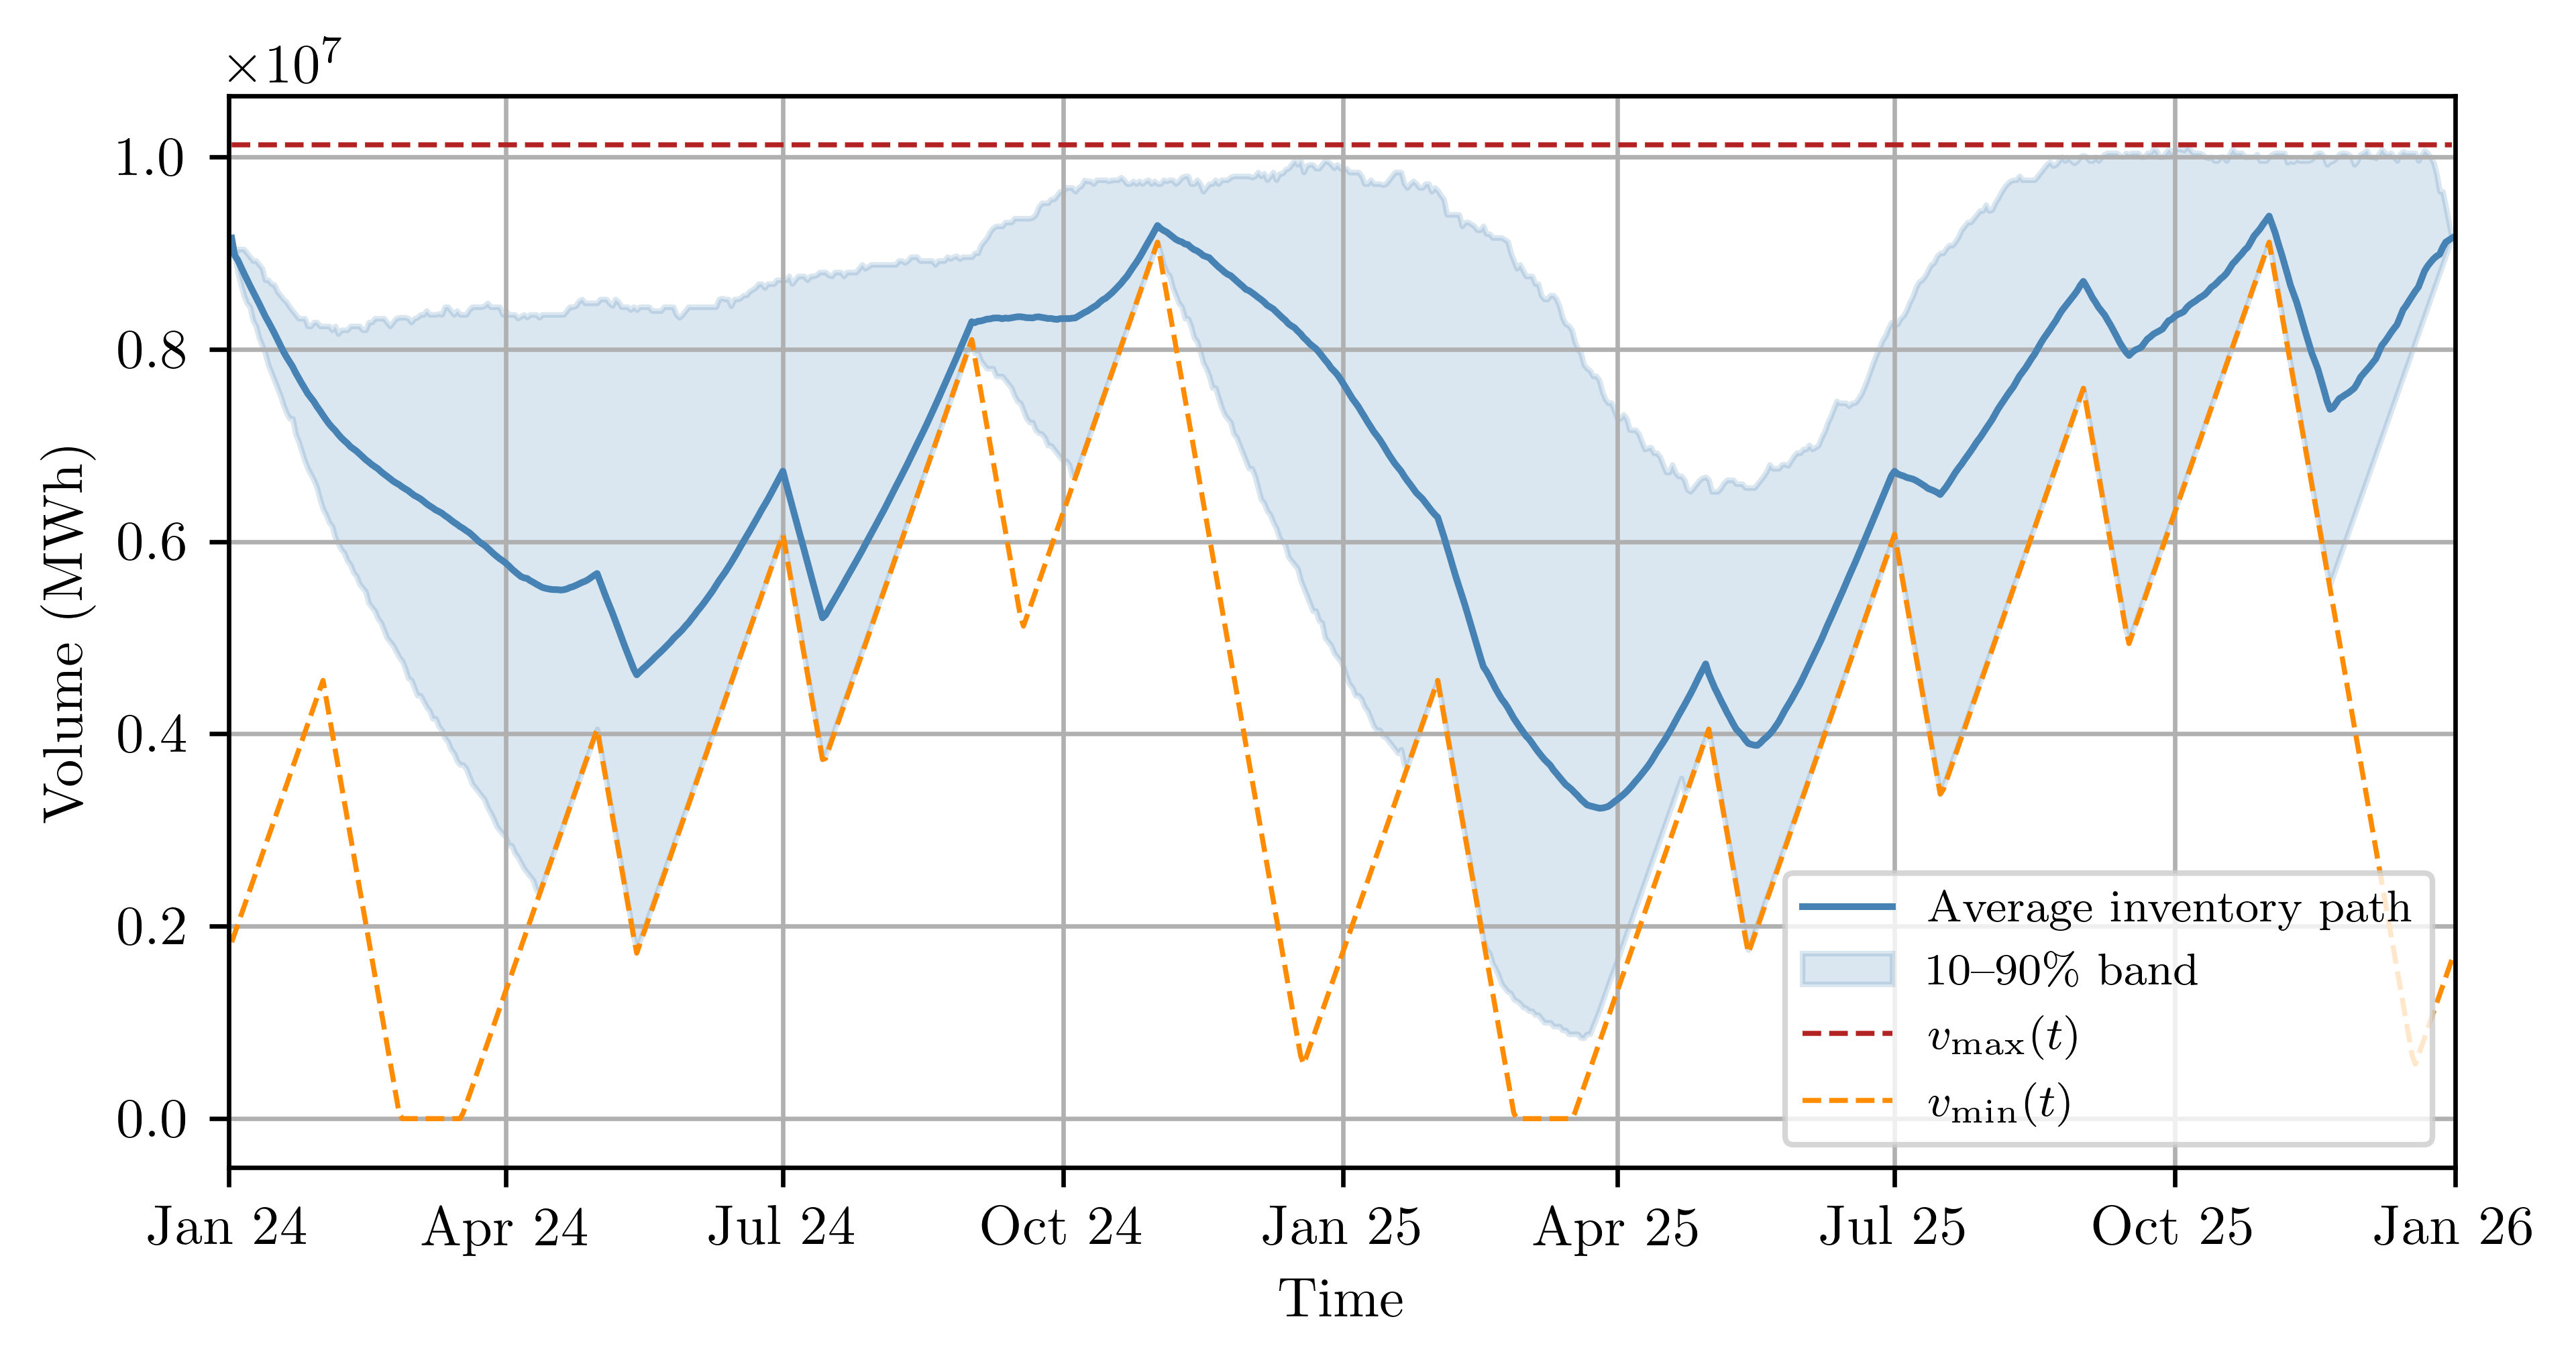

In [5]:
avg_path = v_path.mean(axis=1)
p10      = np.percentile(v_path, 10, axis=1)
p90      = np.percentile(v_path, 90, axis=1)

# Convert numpy datetime64 dates to pandas for plotting
dates_pd = pd.DatetimeIndex(dates)

x_start = pd.Timestamp("2024-01-01")
x_end   = pd.Timestamp("2026-01-01")

# ---- Plot ----
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif":  ["Computer Modern Roman"],
})

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

# Inventory paths
ax.plot(dates_pd, avg_path, color="steelblue", lw=1.2,
        label="Average inventory path")
ax.fill_between(dates_pd, p10, p90, alpha=0.2, color="steelblue",
                label=r"10--90\% band")

# Constraint curves — use the calendar-day arrays from cell 0 directly
ax.step(dates_pd, vmax_arr, where="post", color="firebrick",
        lw=0.9, ls="--", label=r"$v_{\max}(t)$")
ax.plot(dates_pd, vmin_arr, color="darkorange",
        lw=0.9, ls="--", label=r"$v_{\min}(t)$")

ax.set_xlabel("Time")
ax.set_ylabel("Volume (MWh)")
ax.grid(True)

tick_dates = pd.date_range(start=x_start, end=pd.Timestamp("2026-01-01"), freq="3MS")
ax.set_xlim(x_start, x_end)
ax.set_xticks([mdates.date2num(d) for d in tick_dates])
ax.set_xticklabels([d.strftime("%b %y") for d in tick_dates])

ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.savefig("../../fig/Plots/KAN_realised_paths_GSD_10000.png")
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\h'
<>:14: SyntaxWarning: invalid escape sequence '\h'
/var/folders/5j/jwmnpjk12gd85jt5f8996m740000gn/T/ipykernel_64242/1092000027.py:14: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("Pathwise $\hat{V}_0$ [EUR (millions)]")


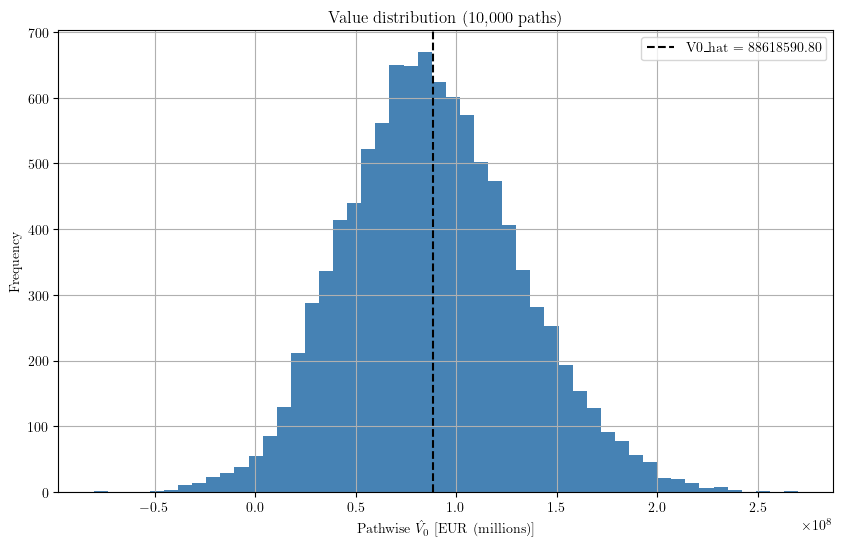

In [6]:
# Calculate V0_hat_pathwise for each path using v_path and S_sim
dv_path = np.diff(v_path, axis=0)            # inventory change from t to t+1
cashflow = -S_sim[:-1] * dv_path            # buy -> negative, sell -> positive

# Discount each calendar-day step back to time 0.
disc_to_0 = np.concatenate(([1.0], np.cumprod(disc_arr[:-1])))
V0_hat_pathwise = np.sum(disc_to_0[:, None] * cashflow, axis=0)

# Plot frequency of V0_hat_pathwise
plt.figure(figsize=(10, 6))
plt.hist(V0_hat_pathwise, bins=50, alpha=1, color="steelblue")
plt.axvline(V0_hat, color="black", linestyle="--", label=f"V0_hat = {V0_hat:.2f}")
plt.title("Value distribution (10,000 paths)")
plt.xlabel("Pathwise $\hat{V}_0$ [EUR (millions)]")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.savefig("../../fig/Plots/KAN_V0_hat_distribution_GSD_10000.png")
plt.show()

In [7]:
# ============================================================
# Out-of-sample valuation using stored KAN models
# ============================================================
def oos_value_from_model_store(S_test: np.ndarray, model_store: list) -> float:
    """
    Evaluate V0 out-of-sample via forward simulation.

    The KAN continuation-value models (model_store) come from a separate
    training run on S_train.  Here we roll the trained policy forward on fresh
    test paths S_test — no new training is performed — recording the realised
    cashflows at each step and discounting them back to t=0.

    This avoids the look-ahead bias of the in-sample backward-DP estimate and
    gives a true lower bound on the storage value.
    """
    M = S_test.shape[1]

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)
    n_path_idx = np.empty((T + 1, M), dtype=np.int32)
    forward_simulate_paths_kan(n_path_idx, S_test, model_store, C_hat_fine_buf)

    # Realised cashflow at step t: sell/buy (v_{t+1} - v_t) MWh at price S_t.
    # Injection (dv > 0) costs -S_t * dv; withdrawal (dv < 0) earns -S_t * dv.
    dv_paths = v_fine[n_path_idx[1:]] - v_fine[n_path_idx[:-1]]   # (T, M)
    cf       = -S_test[:T] * dv_paths                              # (T, M)

    # Cumulative discount from t=0: cashflow at step t is multiplied by
    # disc_arr[0] * ... * disc_arr[t-1]  (cashflow at t=0 is undiscounted).
    cum_disc     = np.ones(T, dtype=np.float64)
    cum_disc[1:] = np.cumprod(disc_arr[:-1])

    pv = np.sum(cf * cum_disc[:, None], axis=0)   # (M,)

    # Paths that do not end at nT_f are infeasible — assign terminal penalty.
    at_target = (n_path_idx[T] == nT_f)
    n_failed  = int(np.sum(~at_target))
    if n_failed > 0:
        print(f"  OOS: {n_failed}/{M} paths did not reach terminal target.")
    pv[~at_target] = np.nan
    return float(np.nanmean(pv))


# ============================================================
# Run: train on S_sim, evaluate out-of-sample on S_test
# ============================================================
# Fresh test paths — independent seed, same antithetic structure
seed_oos   = seed + 1
rng_oos    = np.random.default_rng(seed_oos)
n_half_oos = int(np.ceil(n_paths_max / 2))
Z_half_oos = rng_oos.standard_normal(size=(Tn - 1, n_half_oos))
Z_oos      = np.concatenate([Z_half_oos, -Z_half_oos], axis=1)[:, :n_paths_max]
S_test     = simulate_from_Z(Z_oos, n_paths=n_paths_max, Tn=Tn, t_arr=t_arr,
                              kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col)

V0_hat_oos = oos_value_from_model_store(S_test, model_store)
print(f"V0_hat (out-of-sample) = {V0_hat_oos:,.2f}")

V0_hat (out-of-sample) = 86,649,189.37


In [ ]:
import numpy as np
import numba as nb
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import torch
from kan import KAN
import re
import sys
from io import StringIO
import contextlib

from tqdm import tqdm

# ----------------------------
# Settings
# ----------------------------
n_paths_max = 10000
dt = 1.0  # one calendar-day step (used for OLS calibration on trading-day data)
seed = 123

forward_csv_path = "../data/forward_prices.csv"

# ----------------------------
# Load spot data
# ----------------------------
with open("../data/THE_gas.txt", "r", encoding="utf-8") as f:
    txt = " ".join(f.readlines())

dates_str = re.search(r"labels:\s*\[(.*?)\]", txt).group(1)
dates = [d.replace("'", "").strip() for d in dates_str.split(",")]

prices_str = re.search(r"data:\s*\[(.*?)\]", txt).group(1)
prices = [p.strip() for p in prices_str.split(",")]
prices = [np.nan if p == "" else float(p) for p in prices]

data = pd.DataFrame({
    "date":       pd.to_datetime(dates, format="%d.%m.%Y"),
    "spot_price": prices,
})

data = (
    data
    .dropna(subset=["spot_price"])
    .loc[(data["date"] >= "2024-01-02") & (data["date"] <= "2025-12-31")]
    .sort_values("date")
    .drop_duplicates(subset=["date"])
    .reset_index(drop=True)
)

# ----------------------------
# Load forward curve
# ----------------------------
forward_curve = pd.read_csv(forward_csv_path)
forward_curve["date"] = pd.to_datetime(forward_curve["date"]).dt.normalize()

# ----------------------------
# Joint estimation of seasonality + AR(1)
# ----------------------------
data["t"]     = (data["date"] - data["date"].iloc[0]).dt.days.astype(float)
data["X"]     = np.log(data["spot_price"].astype(float))
data["X_lag"] = data["X"].shift(1)

reg_df = data.dropna(subset=["X", "X_lag"]).copy()
t_reg  = reg_df["t"].to_numpy()

sin1 = np.sin(2.0 * np.pi * t_reg / 365.0)
cos1 = np.cos(2.0 * np.pi * t_reg / 365.0)

Xreg      = sm.add_constant(np.column_stack([reg_df["X_lag"].to_numpy(), sin1, cos1]))
fit_joint = sm.OLS(reg_df["X"].to_numpy(), Xreg).fit()

const_hat     = float(fit_joint.params[0])
b_hat         = float(fit_joint.params[1])
c1_hat        = float(fit_joint.params[2])
c2_hat        = float(fit_joint.params[3])
sigma_eta_hat = float(np.std(fit_joint.resid, ddof=1))

kappa_hat = -np.log(b_hat) / dt
sigma_hat = np.sqrt(
    (sigma_eta_hat**2) * 2.0 * kappa_hat / (1.0 - np.exp(-2.0 * kappa_hat * dt))
)

# ----------------------------
# Build calendar-day simulation grid
# (forward_prices.csv already has all calendar days — direct merge)
# ----------------------------
_cal_start = data["date"].iloc[0]
_cal_end   = data["date"].iloc[-1]
sim_df = pd.DataFrame({"date": pd.date_range(_cal_start, _cal_end, freq="D")})
sim_df = sim_df.merge(forward_curve, on="date", how="inner")
sim_df = sim_df.sort_values("date").reset_index(drop=True)

data  = sim_df.copy()
data["t"]   = (data["date"] - data["date"].iloc[0]).dt.days.astype(float)
data["F0t"] = data["forward_price"].astype(float)

Tn    = len(data)
t_arr = data["t"].to_numpy()

var_X  = (sigma_hat**2 / (2.0 * kappa_hat)) * (1.0 - np.exp(-2.0 * kappa_hat * t_arr))
m      = np.log(data["F0t"].to_numpy()) - 0.5 * var_X
m_col  = m[:, None]

# ----------------------------
# Simulate paths (antithetic normals)
# ----------------------------
rng    = np.random.default_rng(seed)
n_half = int(np.ceil(n_paths_max / 2))
Z_half = rng.standard_normal(size=(Tn - 1, n_half))
Z      = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_paths_max]

def simulate_from_Z(Z, *, n_paths, Tn, t_arr, kappa_hat, sigma_hat, m_col):
    Z_use = Z[:, :n_paths]
    Y = np.zeros((Tn, n_paths), dtype=np.float64)
    for i in range(1, Tn):
        h     = t_arr[i] - t_arr[i - 1]
        phi_h = np.exp(-kappa_hat * h)
        sd_h  = np.sqrt(sigma_hat**2 / (2.0 * kappa_hat) * (1.0 - np.exp(-2.0 * kappa_hat * h)))
        Y[i]  = phi_h * Y[i - 1] + sd_h * Z_use[i - 1]
    return np.exp(Y + m_col)

# ============================================================
# MODEL PARAMETERS — defined before any arrays that depend on them
# ============================================================
alpha_c          = 40000.0
refine_factor    = 16
alpha_f          = alpha_c / refine_factor   # 2 500

r_annual         = 0.1
terminal_penalty = -np.inf

# KAN hyper-parameters
KAN_HIDDEN = 4
KAN_GRID   = 3
KAN_K      = 3
KAN_STEPS  = 5
KAN_LAMBDA = 0.0
KAN_OPT    = "LBFGS"
KAN_MAX_TRAIN_SAMPLES = 300
KAN_BATCH  = KAN_MAX_TRAIN_SAMPLES  # full batch
DEVICE     = torch.device("cpu")

# Step-varying discount: accounts for multi-day gaps (e.g. 3 days for Fri->Mon, 5 for Easter/Christmas)
disc_arr = np.exp(-r_annual * np.diff(t_arr) / 365.0)   # shape (T,), disc_arr[t] for step t->t+1

# ============================================================
# Constraint helpers
# ============================================================

# ---------- vmax: constant ----------
VMAX_CONST = 10_125_000.0

# ---------- Rate caps ----------
INJECTMAX_BASE = 3_780.0 * 24.0
WDRMAX_BASE    = 7_500.0 * 24.0

# ---------- vmin: technical-feasibility floor from dated anchors ----------
# Use the same approach as GSD_min_max_inventory_constraints.ipynb:
# at each date, require enough inventory to still be able to reach every
# future anchor under maximum daily injection.
VMIN_BASE = 0.0
_VMIN_CYCLE_START = pd.Timestamp("2024-01-01")
_VMIN_CYCLE_LENGTH = 365 + 366
# Anchor dates are exact calendar dates — no snapping needed.
_RAW_ANCHOR_DATES = pd.to_datetime([
    "2024-02-01",
    "2024-05-01",
    "2024-07-01",
    "2024-09-01",
    "2024-11-01",
    "2025-02-01",
    "2025-05-01",
    "2025-07-01",
    "2025-09-01",
    "2025-11-01",
])
_VMIN_ANCHOR_DATES = pd.DatetimeIndex(_RAW_ANCHOR_DATES)
_VMIN_ANCHOR_VALUES = VMAX_CONST * np.array([
    0.45, 0.40, 0.60, 0.80, 0.90,
    0.45, 0.40, 0.60, 0.75, 0.90,
], dtype=np.float64)
_VMIN_ANCHOR_X = (_VMIN_ANCHOR_DATES - _VMIN_CYCLE_START).days.to_numpy()
# Include previous/current/next cycles so the floor respects both
# backward-looking withdrawal feasibility and forward-looking injection
# feasibility across the two-year repeating pattern.
_VMIN_ANCHOR_X_ALL = np.r_[
    _VMIN_ANCHOR_X - _VMIN_CYCLE_LENGTH,
    _VMIN_ANCHOR_X,
    _VMIN_ANCHOR_X + _VMIN_CYCLE_LENGTH,
]
_VMIN_ANCHOR_Y_ALL = np.r_[
    _VMIN_ANCHOR_VALUES,
    _VMIN_ANCHOR_VALUES,
    _VMIN_ANCHOR_VALUES,
]

def feasible_vmin_for_dates(dates_like) -> np.ndarray:
    dates = pd.DatetimeIndex(dates_like)
    date_x = (dates - _VMIN_CYCLE_START).days.to_numpy()
    feasible_floor = np.empty(len(dates), dtype=np.float64)
    inj_max = INJECTMAX_BASE
    wdr_max = WDRMAX_BASE
    for i, t in enumerate(date_x):
        future_mask = _VMIN_ANCHOR_X_ALL >= t
        past_mask   = _VMIN_ANCHOR_X_ALL <= t

        days_to_future = _VMIN_ANCHOR_X_ALL[future_mask] - t
        days_from_past = t - _VMIN_ANCHOR_X_ALL[past_mask]

        required_for_future = (
            _VMIN_ANCHOR_Y_ALL[future_mask] - inj_max * days_to_future
        ).max()
        required_from_past = (
            _VMIN_ANCHOR_Y_ALL[past_mask] - wdr_max * days_from_past
        ).max()

        feasible_floor[i] = np.clip(
            max(required_for_future, required_from_past),
            VMIN_BASE,
            VMAX_CONST,
        )
    return feasible_floor

def vmin_at_date(date: pd.Timestamp) -> float:
    return float(feasible_vmin_for_dates(pd.DatetimeIndex([date]))[0])

def inj_cap(fill_frac: float) -> float:
    return (0.75 if fill_frac >= 0.95 else 1.00) * INJECTMAX_BASE

def wdr_cap(fill_frac: float) -> float:
    if   fill_frac <= 0.05:  cap = 0.25
    elif fill_frac <= 0.125: cap = 0.50
    elif fill_frac <= 0.15:  cap = 0.75
    elif fill_frac <= 0.20:  cap = 0.85
    else:                    cap = 1.00
    return cap * WDRMAX_BASE

# ============================================================
# Per-date constraint arrays  (alpha_f now defined above)
# ============================================================
dates_pd = pd.DatetimeIndex(data["date"].to_numpy())

vmax_arr = np.full(len(dates_pd), VMAX_CONST, dtype=np.float64)
vmin_arr = feasible_vmin_for_dates(dates_pd)

# v0 and vT_target: fixed level, snapped to fine grid
v_target_raw = 9_153_925.0
v0        = round(v_target_raw / alpha_f) * alpha_f
vT_target = round(v_target_raw / alpha_f) * alpha_f

print(f"v0        = {v0:>12,.0f}  (snapped from {v_target_raw:,.0f})")
print(f"vT_target = {vT_target:>12,.0f}  (snapped from {v_target_raw:,.0f})")
print(f"vmax range: {vmax_arr.min():,.0f} – {vmax_arr.max():,.0f}")
print(f"vmin range: {vmin_arr.min():,.0f} – {vmin_arr.max():,.0f}")


# ============================================================
# Volume grid
# ============================================================
VMIN_GLOBAL = 0.0
VMAX_GLOBAL = float(np.max(vmax_arr))

Nc = int(round((VMAX_GLOBAL - VMIN_GLOBAL) / alpha_c)) + 1
Nf = (Nc - 1) * refine_factor + 1

v_coarse        = VMIN_GLOBAL + alpha_c * np.arange(Nc, dtype=np.float64)
v_fine          = VMIN_GLOBAL + alpha_f * np.arange(Nf, dtype=np.float64)
coarse_fine_idx = (refine_factor * np.arange(Nc)).astype(np.int32)
assert coarse_fine_idx[-1] == Nf - 1, "Grid alignment check failed"

def fine_index_of(v: float) -> int:
    return int(round((v - VMIN_GLOBAL) / alpha_f))

n0_f  = fine_index_of(v0)
nT_f  = fine_index_of(vT_target)

print(f"\nGrid: Nc={Nc}, Nf={Nf}, n0_f={n0_f}, nT_f={nT_f}")

# ============================================================
# Terminal value: hard target at nT_f.
# ============================================================
def terminal_value(v_arr: np.ndarray) -> np.ndarray:
    tv = np.full_like(v_arr, terminal_penalty, dtype=np.float64)
    tv[nT_f] = 0.0
    return tv

# ============================================================
# Feasible action sets — one per timestep
# ============================================================
def build_feasible_actions_at_t(t_idx: int):
    """
    Transition t → t+1.
    Origin:      vmin(t)   <= v  <= vmax(t)
    Destination: vmin(t+1) <= v' <= vmax(t+1)
    Subject to injection/withdrawal rate caps scaled by the actual number
    of calendar days elapsed between observations (handles weekends/holidays
    where t_arr jumps by 3+ days and the rate cap must scale accordingly).
    """
    vm_t    = vmax_arr[t_idx]
    vn_t    = vmin_arr[t_idx]
    t_next  = min(t_idx + 1, len(vmax_arr) - 1)
    vm_next = vmax_arr[t_next]
    vn_next = vmin_arr[t_next]

    # Calendar days between this observation and the next.
    # t_arr is in elapsed days from the first date.
    days = float(t_arr[t_next] - t_arr[t_idx]) if t_next != t_idx else 1.0
    days = max(days, 1.0)   # safety: never less than 1

    # First pass: determine K_max
    K_max_t = 0
    for n_f in range(Nf):
        v = v_fine[n_f]
        if v < vn_t - 1e-6 or v > vm_t + 1e-6:
            continue
        fill          = v / vm_t
        max_inj_total = inj_cap(fill) * days
        max_wdr_total = wdr_cap(fill) * days
        dv_lo = max(vn_next - v, -max_wdr_total)
        dv_hi = min(vm_next - v,  max_inj_total)
        k_lo  = int(np.ceil(dv_lo  / alpha_f))
        k_hi  = int(np.floor(dv_hi / alpha_f))
        K_max_t = max(K_max_t, max(0, k_hi - k_lo + 1))

    K_max_t = max(K_max_t, 1)

    next_idx = np.full((Nf, K_max_t), -1, dtype=np.int32)
    dv_mat   = np.zeros((Nf, K_max_t), dtype=np.float64)
    K_len    = np.zeros(Nf, dtype=np.int32)

    for n_f in range(Nf):
        v = v_fine[n_f]
        if v < vn_t - 1e-6 or v > vm_t + 1e-6:
            continue
        fill          = v / vm_t
        max_inj_total = inj_cap(fill) * days
        max_wdr_total = wdr_cap(fill) * days
        dv_lo = max(vn_next - v, -max_wdr_total)
        dv_hi = min(vm_next - v,  max_inj_total)
        k_lo  = int(np.ceil(dv_lo  / alpha_f))
        k_hi  = int(np.floor(dv_hi / alpha_f))
        if k_hi < k_lo:
            continue
        idxs = n_f + np.arange(k_lo, k_hi + 1, dtype=np.int32)
        idxs = idxs[(idxs >= 0) & (idxs < Nf)]
        k    = idxs.size
        K_len[n_f] = k
        if k:
            next_idx[n_f, :k] = idxs
            dv_mat[n_f,   :k] = v_fine[idxs] - v

    return next_idx, dv_mat, K_len

print("Pre-computing feasible action sets …")
all_next_idx = []
all_dv_mat   = []
all_K_len    = []
all_dest_ok  = []   # bool[Nf]: valid destination nodes at t+1

for t_idx in range(Tn):
    ni, dv, kl = build_feasible_actions_at_t(t_idx)
    all_next_idx.append(ni)
    all_dv_mat.append(dv)
    all_K_len.append(kl)

    t_next  = min(t_idx + 1, len(vmax_arr) - 1)
    all_dest_ok.append(
        (v_fine >= vmin_arr[t_next] - 1e-6) &
        (v_fine <= vmax_arr[t_next] + 1e-6)
    )

T = Tn - 1
all_can_reach = [np.zeros(Nf, dtype=np.bool_) for _ in range(T + 1)]
all_can_reach[T][nT_f] = True
for t_idx in range(T - 1, -1, -1):
    can_reach_next = all_can_reach[t_idx + 1]
    can_reach_now  = all_can_reach[t_idx]
    ni_t = all_next_idx[t_idx]
    kl_t = all_K_len[t_idx]
    for n_f in range(Nf):
        klen = kl_t[n_f]
        if klen == 0:
            continue
        can_reach_now[n_f] = np.any(can_reach_next[ni_t[n_f, :klen]])

print("Done.")

# ============================================================
# Output suppression helper
# ============================================================
@contextlib.contextmanager
def suppress_output():
    """Context manager to suppress stdout and stderr."""
    save_stdout = sys.stdout
    save_stderr = sys.stderr
    sys.stdout = StringIO()
    sys.stderr = StringIO()
    try:
        yield
    finally:
        sys.stdout = save_stdout
        sys.stderr = save_stderr

# ============================================================
# KAN continuation estimator
# ============================================================
def train_kan_node(S_col: np.ndarray, y_col: np.ndarray, init_params=None):
    """Train one KAN for a single (t, coarse-node) continuation fit."""
    mask = np.isfinite(y_col)
    if mask.sum() < 4:
        return None

    S_ok = S_col[mask].astype(np.float32)
    y_ok = y_col[mask].astype(np.float32)
    if S_ok.shape[0] > KAN_MAX_TRAIN_SAMPLES:
        # Subsample for stable runtime when the path count is large.
        idx = np.random.default_rng(seed + S_ok.shape[0]).choice(
            S_ok.shape[0], KAN_MAX_TRAIN_SAMPLES, replace=False
        )
        S_ok = S_ok[idx]
        y_ok = y_ok[idx]

    s_mean = float(S_ok.mean())
    s_std  = float(S_ok.std()) + 1e-8
    y_mean = float(y_ok.mean())
    y_std  = float(y_ok.std()) + 1e-8

    X_t = torch.from_numpy(((S_ok - s_mean) / s_std)[:, None]).to(DEVICE, dtype=torch.float32)
    y_t = torch.from_numpy(((y_ok - y_mean) / y_std)[:, None]).to(DEVICE, dtype=torch.float32)

    dataset = {
        "train_input": X_t,
        "train_label": y_t,
        "test_input": X_t,
        "test_label": y_t,
    }

    model = KAN(
        width=[1, KAN_HIDDEN, 1],
        grid=KAN_GRID,
        k=KAN_K,
        seed=seed,
        device=DEVICE,
        save_act=False,
        auto_save=False,
    )
    if init_params is not None:
        model.load_state_dict(init_params[0].state_dict())

    batch_size = X_t.shape[0]  # full batch (KAN_BATCH == KAN_MAX_TRAIN_SAMPLES)
    with suppress_output():
        model.fit(
            dataset,
            opt=KAN_OPT,
            steps=KAN_STEPS,
            lamb=KAN_LAMBDA,
            batch=batch_size,
            update_grid=False,
            save_fig=False,
            log=KAN_STEPS,
            display_metrics=None,
        )
    model.eval()
    return model, s_mean, s_std, y_mean, y_std

def eval_kan_node(params, S_col: np.ndarray) -> np.ndarray:
    if params is None:
        return np.zeros(S_col.shape[0], dtype=np.float64)

    model, s_mean, s_std, y_mean, y_std = params
    X_t = torch.from_numpy((((S_col.astype(np.float32) - s_mean) / s_std)[:, None])).to(DEVICE, dtype=torch.float32)
    with torch.no_grad():
        y_norm = model(X_t).detach().cpu().numpy().reshape(-1)
    return (y_norm * y_std + y_mean).astype(np.float64)

# ============================================================
# Numba kernels
# ============================================================

@nb.njit(parallel=True, fastmath=True)
def interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                coarse_fine_idx, refine_factor):
    M, Nc = C_hat_coarse.shape
    for i in nb.prange(M):
        for k in range(Nc):
            C_hat_fine_buf[i, coarse_fine_idx[k]] = C_hat_coarse[i, k]
    if refine_factor == 1:
        return
    for i in nb.prange(M):
        for k in range(Nc - 1):
            lf    = coarse_fine_idx[k]
            left  = C_hat_coarse[i, k]
            right = C_hat_coarse[i, k + 1]
            for j in range(1, refine_factor):
                w = j / refine_factor
                C_hat_fine_buf[i, lf + j] = (1.0 - w) * left + w * right

@nb.njit(parallel=True, fastmath=True)
def clamp_infeasible(C_hat_fine_buf, dest_ok, terminal_penalty):
    M  = C_hat_fine_buf.shape[0]
    Nf = C_hat_fine_buf.shape[1]
    for i in nb.prange(M):
        for n in range(Nf):
            if not dest_ok[n]:
                C_hat_fine_buf[i, n] = terminal_penalty

@nb.njit(parallel=True, fastmath=True)
def bellman_update_numba(Y_current, Y_next, pi_next_idx_t, n_curr, S_t, C_hat_fine,
                         next_idx_mat, dv_mat, K_len, disc_t, terminal_penalty):
    M  = S_t.shape[0]
    Nf = next_idx_mat.shape[0]
    for i in nb.prange(M):
        s          = S_t[i]
        n_realized = n_curr[i]
        pi_next_idx_t[i] = -1
        for n_f in range(Nf):
            klen = K_len[n_f]
            if klen == 0:
                Y_current[i, n_f] = terminal_penalty
                continue
            best_val  = terminal_penalty
            best_next = -1
            best_dv   = 0.0
            for k in range(klen):
                nxt = next_idx_mat[n_f, k]
                dv  = dv_mat[n_f, k]
                cand = (-s * dv) + C_hat_fine[i, nxt]
                if cand > best_val:
                    best_val  = cand
                    best_next = nxt
                    best_dv   = dv
            Y_current[i, n_f] = (-s * best_dv) + disc_t * Y_next[i, best_next]
            if n_f == n_realized:
                pi_next_idx_t[i] = best_next

def forward_simulate_paths_kan(n_path_idx, S, model_store, C_hat_fine_buf):
    Tloc = S.shape[0] - 1
    Mloc = S.shape[1]
    n_path_idx[0] = n0_f

    for t in range(Tloc):
        S_t = S[t].astype(np.float64, copy=False)
        C_hat_coarse = np.zeros((Mloc, Nc), dtype=np.float64)
        reach_next = all_can_reach[t + 1]
        for j in range(Nc):
            if not reach_next[coarse_fine_idx[j]]:
                continue
            C_hat_coarse[:, j] = eval_kan_node(model_store[t][j], S_t)

        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                   coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, reach_next, terminal_penalty)

        ni_t = all_next_idx[t]
        dv_t = all_dv_mat[t]
        kl_t = all_K_len[t]
        for i in range(Mloc):
            n = n_path_idx[t, i]
            klen = kl_t[n]
            s = S_t[i]
            best_val = terminal_penalty
            best_next = -1
            for kk in range(klen):
                nxt = ni_t[n, kk]
                dv = dv_t[n, kk]
                cand = (-s * dv) + C_hat_fine_buf[i, nxt]
                if cand > best_val:
                    best_val = cand
                    best_next = nxt
            n_path_idx[t + 1, i] = best_next if best_next != -1 else n

# ============================================================
# LSMC main function
# ============================================================
def lsmc_value_and_paths_given_S(S: np.ndarray):
    T = S.shape[0] - 1
    M = S.shape[1]

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)

    # ---- Terminal condition ----
    # Hard terminal target: zero payoff at nT_f, -inf elsewhere.
    tv        = terminal_value(v_fine)                   # (Nf,)
    Y_next    = np.tile(tv, (M, 1))                      # (M, Nf)
    Y_next[:, ~all_dest_ok[-1]] = terminal_penalty

    Y_current   = np.empty((M, Nf), dtype=np.float64)
    pi_dtype    = np.int16 if Nf <= np.iinfo(np.int16).max else np.int32
    pi_next_idx = np.empty((T, M), dtype=pi_dtype)
    n_curr      = np.full(M, nT_f, dtype=np.int32)

    model_store = [[None] * Nc for _ in range(T)]

    # ---- Backward pass ----
    for t in tqdm(range(T - 1, -1, -1), desc="Backward pass"):
        S_t = S[t].astype(np.float64, copy=False)

        reach_next = all_can_reach[t + 1]
        Y_disc = disc_arr[t] * Y_next[:, coarse_fine_idx]
        C_hat_coarse = np.zeros((M, Nc), dtype=np.float64)
        for j in range(Nc):
            if not reach_next[coarse_fine_idx[j]]:
                continue
            init_params = model_store[t + 1][j] if t + 1 < T else None
            params = train_kan_node(S_t, Y_disc[:, j], init_params=init_params)
            model_store[t][j] = params
            C_hat_coarse[:, j] = eval_kan_node(params, S_t)

        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                   coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, reach_next,
                         terminal_penalty)

        bellman_update_numba(
            Y_current, Y_next, pi_next_idx[t], n_curr, S_t,
            C_hat_fine_buf, all_next_idx[t], all_dv_mat[t], all_K_len[t],
            disc_arr[t], terminal_penalty,
        )

        n_curr = pi_next_idx[t].astype(np.int32)
        Y_next, Y_current = Y_current, Y_next

    V0_hat = float(np.mean(Y_next[:, n0_f]))

    # Save model_store as state_dicts (KAN models contain lambdas that
    # cannot be pickled by torch.save directly).
    model_store_saveable = [
        [(m[0].state_dict(), m[1], m[2], m[3], m[4]) if m is not None else None
         for m in row]
        for row in model_store
    ]
    torch.save(model_store_saveable, "../data/model_store_KAN_GSD.pt")

    # ---- Forward rollout ----
    n_path_idx = np.empty((T + 1, M), dtype=np.int32)
    forward_simulate_paths_kan(n_path_idx, S, model_store, C_hat_fine_buf)

    v_path = v_fine[n_path_idx]
    return V0_hat, v_path, data["date"].to_numpy(), model_store

# ============================================================
# Run once: simulate S, value, then plot inventory band
# ============================================================
S_sim = simulate_from_Z(Z, n_paths=n_paths_max, Tn=Tn, t_arr=t_arr,
                        kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col)

# Reconstruct model_store from saved state_dicts.
_raw = torch.load("../data/model_store_KAN_GSD.pt", weights_only=False)
model_store = []
for row in _raw:
    model_row = []
    for entry in row:
        if entry is None:
            model_row.append(None)
        else:
            sd, s_mean, s_std, y_mean, y_std = entry
            m = KAN(width=[1, KAN_HIDDEN, 1], grid=KAN_GRID, k=KAN_K,
                    seed=seed, device=DEVICE, save_act=False, auto_save=False)
            m.load_state_dict(sd)
            m.eval()
            model_row.append((m, s_mean, s_std, y_mean, y_std))
    model_store.append(model_row)
print(f"Loaded model_store: {len(model_store)} timesteps x {len(model_store[0])} nodes")
del _raw

import gc; gc.collect()

v0        =    9,155,000  (snapped from 9,153,925)
vT_target =    9,155,000  (snapped from 9,153,925)
vmax range: 10,125,000 – 10,125,000
vmin range: 0 – 9,112,500

Grid: Nc=254, Nf=4049, n0_f=3662, nT_f=3662
Pre-computing feasible action sets …
Done.


KeyboardInterrupt: 